In [1]:
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df_level_estresse = pd.read_csv('csv/StressLevelDataset.csv')

In [3]:
df_level_estresse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [4]:
df_level_estresse['stress_level'].value_counts()

stress_level
0    373
2    369
1    358
Name: count, dtype: int64

# Correlacao / Detecção de outliers / Remocao de colunas / Padronizacao:

### Estresse / Level de ansiedade:

In [5]:
correlacao = np.corrcoef(df_level_estresse['anxiety_level'],df_level_estresse['stress_level']) 
correlacao # correlacao forte positiva

array([[1.        , 0.73679542],
       [0.73679542, 1.        ]])

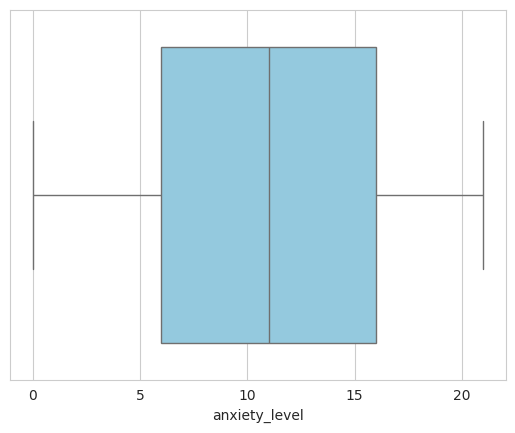

In [6]:
with sns.axes_style('whitegrid'):
    grafico = sns.boxplot(data = df_level_estresse, x = 'anxiety_level',color = 'skyblue')
    # Sem outliers

In [7]:
media_ansi = df_level_estresse['anxiety_level'].mean()
desvio_padrao_ansi = df_level_estresse['anxiety_level'].std()

df_level_estresse['anxiety_level'] = df_level_estresse['anxiety_level'].apply(lambda x : (x - media_ansi) / desvio_padrao_ansi)

### Estresse / Auto-estima:

In [8]:
correlacao = np.corrcoef(df_level_estresse['self_esteem'],df_level_estresse['stress_level'])
correlacao # correlacao forte negativa

array([[ 1.        , -0.75619509],
       [-0.75619509,  1.        ]])

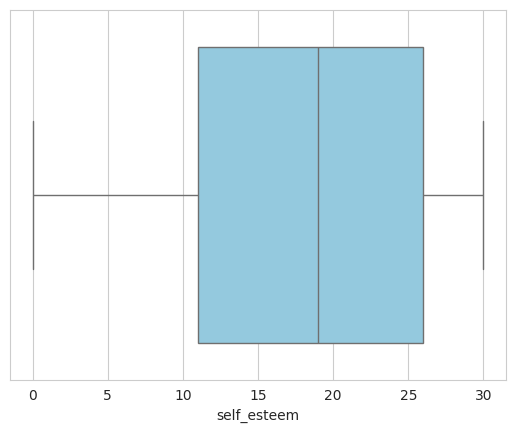

In [9]:
with sns.axes_style('whitegrid'):
    grafico = sns.boxplot(data = df_level_estresse, x = 'self_esteem', color = 'skyblue')
    # Sem outliers

In [10]:
media_auto = df_level_estresse['self_esteem'].mean()
desvio_padrao_auto = df_level_estresse['self_esteem'].std()

df_level_estresse['self_esteem'] = df_level_estresse['self_esteem'].apply(lambda x : (x - media_auto) / desvio_padrao_auto)

In [11]:
df_level_estresse.drop(columns={'self_esteem'},inplace= True)

### Estresse / Historico mental:

In [12]:
correlacao = np.corrcoef(df_level_estresse['mental_health_history'],df_level_estresse['stress_level'])
correlacao # correlacao forte positiva
# 1 = sim / 0 = nao

array([[1.      , 0.648644],
       [0.648644, 1.      ]])

In [13]:
media_mental = df_level_estresse['mental_health_history'].mean()
desvio_padrao_mental = df_level_estresse['mental_health_history'].std()

df_level_estresse['mental_health_history'] = df_level_estresse['mental_health_history'].apply(lambda x : (x - media_mental) / desvio_padrao_mental)

### Estresse / Depression:	

In [14]:
correlacao = np.corrcoef(df_level_estresse['depression'],df_level_estresse['stress_level'])
correlacao # correlacao forte positiva

array([[1.        , 0.73437857],
       [0.73437857, 1.        ]])

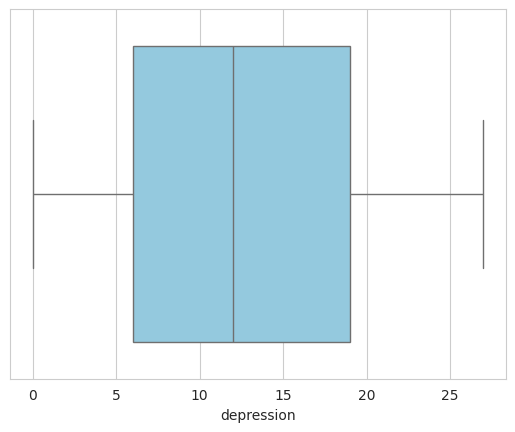

In [15]:
with sns.axes_style('whitegrid'):
    grafico = sns.boxplot(data = df_level_estresse, x = 'depression', color = 'skyblue')
    # Sem outliers

In [16]:
media_depre = df_level_estresse['depression'].mean()
desvio_padrao_depre = df_level_estresse['depression'].std()

df_level_estresse['depression'] = df_level_estresse['depression'].apply(lambda x : (x - media_depre) / desvio_padrao_depre)

### Estresse / dor de cabeca:

In [17]:
correlacao = np.corrcoef(df_level_estresse['headache'],df_level_estresse['stress_level'])
correlacao # correlacao forte positva

array([[1.        , 0.71348404],
       [0.71348404, 1.        ]])

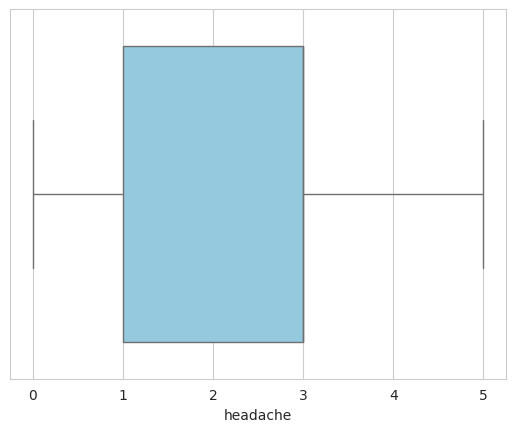

In [18]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'headache', color = 'skyblue')
    # sem outliers

In [19]:
media_cabeca = df_level_estresse['headache'].mean()
desvio_padrao_cabeca = df_level_estresse['headache'].std()

df_level_estresse['headache'] = df_level_estresse['headache'].apply(lambda x : (x - media_cabeca) / desvio_padrao_cabeca)

### Remover pressao sanguinia:

In [20]:
df_level_estresse.drop(columns = {'blood_pressure'},inplace=True)

### Estresse / Qualidade do sono:

In [21]:
correlacao = np.corrcoef(df_level_estresse['sleep_quality'],df_level_estresse['stress_level'])
correlacao # correlacao forte negativa

array([[ 1.        , -0.74906786],
       [-0.74906786,  1.        ]])

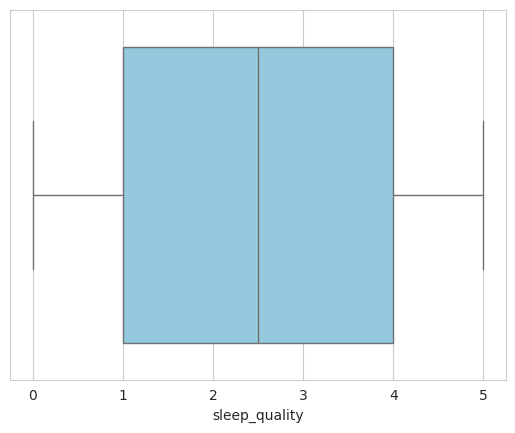

In [22]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'sleep_quality', color = 'skyblue')
    # sem outliers

In [23]:
media_sono = df_level_estresse['sleep_quality'].mean()
desvio_padrao_sono = df_level_estresse['sleep_quality'].std()

df_level_estresse['sleep_quality'] = df_level_estresse['sleep_quality'].apply(lambda x : (x - media_sono) / desvio_padrao_sono)

### Estresse / problemas de respiracao:

In [24]:
correlacao = np.corrcoef(df_level_estresse['breathing_problem'],df_level_estresse['stress_level'])
correlacao # correlacao media positiva

array([[1.        , 0.57398367],
       [0.57398367, 1.        ]])

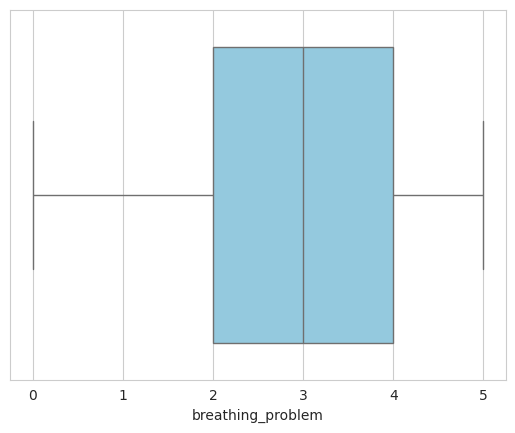

In [25]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'breathing_problem', color = 'skyblue')
    # sem outliers

In [26]:
media_respiracao = df_level_estresse['breathing_problem'].mean()
desvio_padrao_respiracao = df_level_estresse['breathing_problem'].std()

df_level_estresse['breathing_problem'] = df_level_estresse['breathing_problem'].apply(lambda x : (x - media_respiracao) / desvio_padrao_respiracao)

In [27]:
df_level_estresse.drop(columns={'breathing_problem'}, inplace= True)

### Estresse / nivel de ruido:

In [28]:
correlacao = np.corrcoef(df_level_estresse['noise_level'],df_level_estresse['stress_level'])
correlacao # correlacao forte positiva

array([[1.        , 0.66337132],
       [0.66337132, 1.        ]])

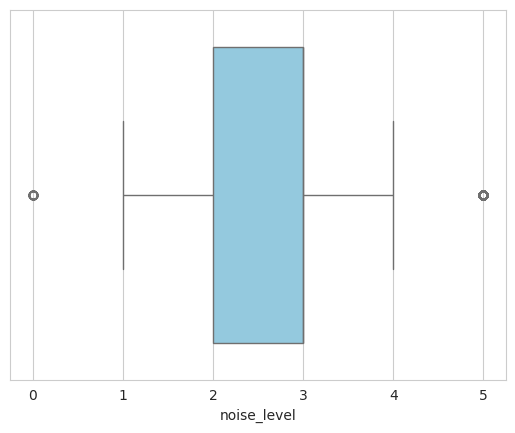

In [29]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'noise_level', color = 'skyblue')
    # com outliers

In [30]:
media_ruido = df_level_estresse['noise_level'].mean()
desvio_padrao_ruido = df_level_estresse['noise_level'].std()

df_level_estresse['noise_level'] = df_level_estresse['noise_level'].apply(lambda x : (x - media_ruido) / desvio_padrao_ruido)

In [31]:
df_level_estresse.drop(columns={'noise_level'}, inplace= True)

### Estresse / Condicao de vida :

In [32]:
correlacao = np.corrcoef(df_level_estresse['living_conditions'],df_level_estresse['stress_level'])
correlacao # correlacao forte negativa

array([[ 1.        , -0.58172308],
       [-0.58172308,  1.        ]])

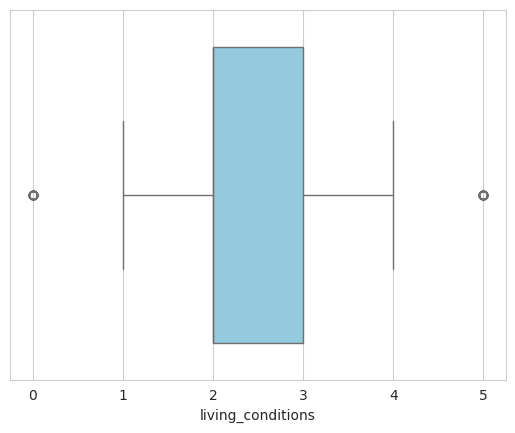

In [33]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'living_conditions', color = 'skyblue')

In [34]:
media_condicao_vida = df_level_estresse['living_conditions'].mean()
desvio_padrao_condicao_vida = df_level_estresse['living_conditions'].std()

df_level_estresse['living_conditions'] = df_level_estresse['living_conditions'].apply(lambda x : (x - media_condicao_vida) / desvio_padrao_condicao_vida)

In [35]:
df_level_estresse['living_conditions'].value_counts()
# nao a necessitade de dar drop

living_conditions
-0.462990    346
 0.430499    327
 1.323988    189
-1.356479    176
 2.217477     33
-2.249968     29
Name: count, dtype: int64

### Estresse / seguranca:

In [36]:
correlacao = np.corrcoef(df_level_estresse['safety'],df_level_estresse['stress_level'])
correlacao # correlacao forte negativa

array([[ 1.        , -0.70960161],
       [-0.70960161,  1.        ]])

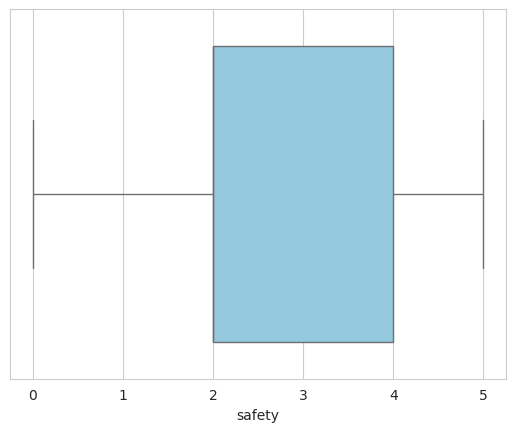

In [37]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'safety', color = 'skyblue')
    # sem outliers

In [38]:
media_seguranca = df_level_estresse['safety'].mean()
desvio_padrao_seguranca = df_level_estresse['safety'].std()

df_level_estresse['safety'] = df_level_estresse['safety'].apply(lambda x : (x - media_seguranca) / desvio_padrao_seguranca)

### Remover necessidades basicas:

In [39]:
df_level_estresse.drop(columns={'basic_needs'},inplace=True)

### Estresse / Desempenho academico:

In [40]:
correlacao = np.corrcoef(df_level_estresse['academic_performance'],df_level_estresse['stress_level'])
correlacao # correlacao forte negativa

array([[ 1.        , -0.72092236],
       [-0.72092236,  1.        ]])

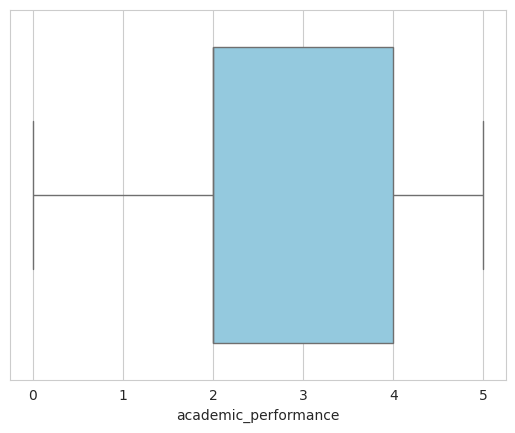

In [41]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'academic_performance', color = 'skyblue')
    # sem outliers

In [42]:
media_performace = df_level_estresse['academic_performance'].mean()
desvio_padrao_performace = df_level_estresse['academic_performance'].std()

df_level_estresse['academic_performance'] = df_level_estresse['academic_performance'].apply(lambda x : (x - media_performace) / media_performace)

### Estresse / Carga de estudo:

In [43]:
correlacao = np.corrcoef(df_level_estresse['study_load'],df_level_estresse['stress_level'])
correlacao # correlacao forte positiva

array([[1.       , 0.6341555],
       [0.6341555, 1.       ]])

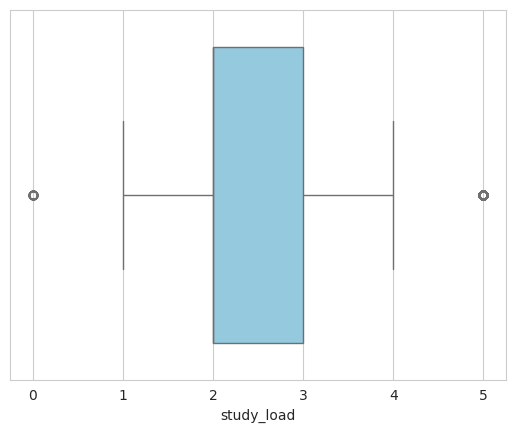

In [44]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'study_load', color = 'skyblue')
    # sem outliers

In [45]:
media_carga_estudo = df_level_estresse['study_load'].mean()
desvio_padrao_carga_estudo = df_level_estresse['study_load'].std()

df_level_estresse['study_load'] = df_level_estresse['study_load'].apply(lambda x : (x - media_carga_estudo) / desvio_padrao_carga_estudo)

In [46]:
df_level_estresse.drop(columns = {'study_load'},inplace= True)

### Estresse / Relacao com os professores:

In [47]:
correlacao = np.corrcoef(df_level_estresse['teacher_student_relationship'],df_level_estresse['stress_level'])
correlacao # correlacao forte negativa

array([[ 1.        , -0.68016274],
       [-0.68016274,  1.        ]])

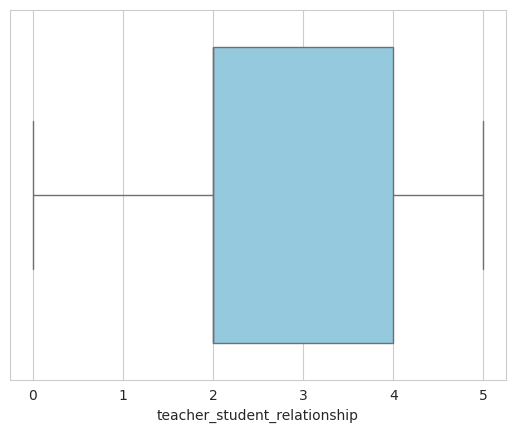

In [48]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'teacher_student_relationship', color = 'skyblue')
    # sem outliers

In [49]:
media_relacao_prof = df_level_estresse['teacher_student_relationship'].mean()
desvio_padrao_relacao_prof = df_level_estresse['teacher_student_relationship'].std()

df_level_estresse['teacher_student_relationship'] = df_level_estresse['teacher_student_relationship'].apply(lambda x : (x - media_relacao_prof) / desvio_padrao_relacao_prof)

### Estresse / Preocupacoes futuras :

In [50]:
correlacao = np.corrcoef(df_level_estresse['future_career_concerns'],df_level_estresse['stress_level'])
correlacao # correlacao forte positiva

array([[1.       , 0.7426186],
       [0.7426186, 1.       ]])

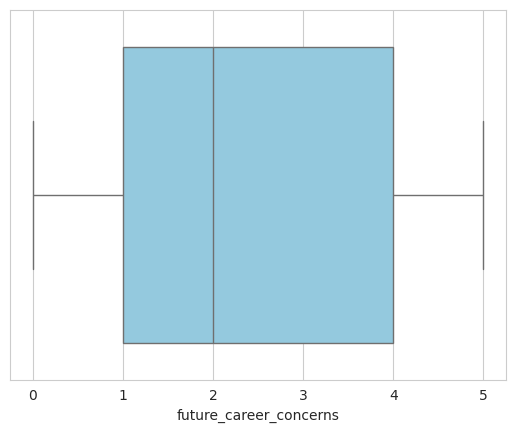

In [51]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'future_career_concerns', color = 'skyblue')
    # sem outliers

In [52]:
media_futuro = df_level_estresse['future_career_concerns'].mean()
desvio_padrao_futuro = df_level_estresse['future_career_concerns'].std()

df_level_estresse['future_career_concerns'] = df_level_estresse['future_career_concerns'].apply(lambda x : (x - media_futuro) / desvio_padrao_futuro)

In [53]:
df_level_estresse.drop(columns={'future_career_concerns'},inplace=True)

### Estresse / Suporte social:

In [54]:
correlacao = np.corrcoef(df_level_estresse['social_support'],df_level_estresse['stress_level'])
correlacao # correlacao forte negativa

array([[ 1.        , -0.63249699],
       [-0.63249699,  1.        ]])

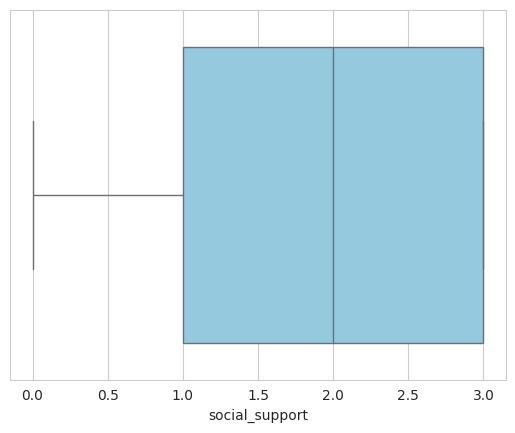

In [55]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'social_support', color = 'skyblue')
    # sem outliers

In [56]:
media_social = df_level_estresse['social_support'].mean()
desvio_padrao_social = df_level_estresse['social_support'].std()

df_level_estresse['social_support'] = df_level_estresse['social_support'].apply(lambda x : (x - media_social) / desvio_padrao_social)

In [57]:
df_level_estresse.drop(columns = {'social_support'},inplace=True)

### Remover pressao :

In [58]:
df_level_estresse.drop(columns={'peer_pressure'},inplace=True)

### Estresse / Atividades extracurriculares :

In [59]:
correlacao = np.corrcoef(df_level_estresse['extracurricular_activities'],df_level_estresse['stress_level'])
correlacao # correlacao forte positiva

array([[1.        , 0.69297687],
       [0.69297687, 1.        ]])

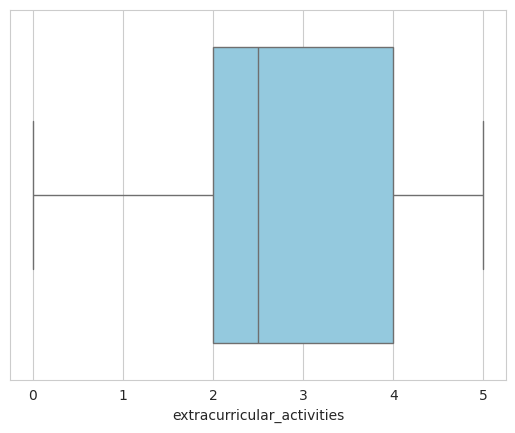

In [60]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'extracurricular_activities', color = 'skyblue')
    # sem outliers

In [61]:
media_ativ = df_level_estresse['extracurricular_activities'].mean()
desvio_padrao_ativ = df_level_estresse['extracurricular_activities'].std()

df_level_estresse['extracurricular_activities'] = df_level_estresse['extracurricular_activities'].apply(lambda x : (x - media_ativ) / desvio_padrao_ativ)

In [62]:
df_level_estresse.drop(columns = {'extracurricular_activities'},inplace= True)

### Estresse / Bullying:

In [63]:
correlacao = np.corrcoef(df_level_estresse['bullying'],df_level_estresse['stress_level'])
correlacao # correlacao forte positiva

array([[1.        , 0.75116225],
       [0.75116225, 1.        ]])

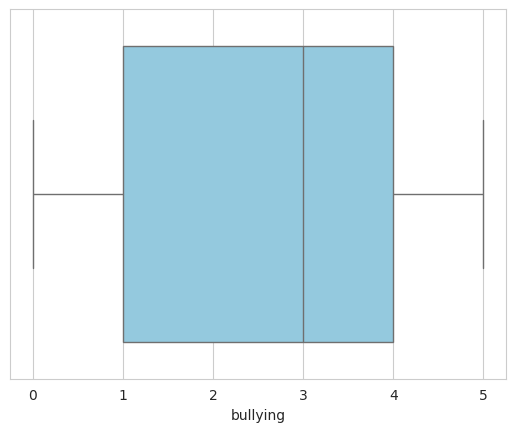

In [64]:
with sns.axes_style('whitegrid'):
    sns.boxplot(data = df_level_estresse, x = 'bullying', color = 'skyblue')
    # sem outliers

In [65]:
media_bully = df_level_estresse['bullying'].mean()
desvio_padrao_bully = df_level_estresse['bullying'].std()

df_level_estresse['bullying'] = df_level_estresse['bullying'].apply(lambda x : (x - media_bully) / desvio_padrao_bully)

# Machine learn:

## Treinamento:

In [66]:
df_level_estresse.describe()

,anxiety_level,mental_health_history,depression,headache,sleep_quality,living_conditions,safety,academic_performance,teacher_student_relationship,bullying,stress_level
count,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1100.000000
mean,-1.356491e-16,6.136505e-17,8.720297e-17,-7.751375e-17,-1.130409e-16,8.235836e-17,-5.167584e-17,-8.114721e-17,1.453383e-16,4.521636e-17,0.996364
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.101813e-01,1.000000e+00,1.000000e+00,0.821673
min,-1.808505e+00,-9.851107e-01,-1.624879e+00,-1.779665e+00,-1.717922e+00,-2.249968e+00,-1.946614e+00,-1.000000e+00,-1.912627e+00,-1.709565e+00,0.000000
25%,-8.277218e-01,-9.851107e-01,-8.483820e-01,-1.070121e+00,-1.072086e+00,-4.629898e-01,-5.243122e-01,-2.786885e-01,-4.681438e-01,-1.056380e+00,0.000000
50%,-1.040225e-02,-9.851107e-01,-7.188481e-02,3.489666e-01,-1.033336e-01,-4.629898e-01,-5.243122e-01,-2.786885e-01,-4.681438e-01,2.499920e-01,1.000000
75%,8.069173e-01,1.014191e+00,8.340285e-01,3.489666e-01,8.654192e-01,4.304993e-01,8.979897e-01,4.426230e-01,9.763391e-01,9.031778e-01,2.000000
max,1.624237e+00,1.014191e+00,1.869358e+00,1.768055e+00,1.511254e+00,2.217477e+00,1.609141e+00,8.032787e-01,1.698581e+00,1.556364e+00,2.000000


In [67]:
model = LinearRegression()

In [68]:
predictors_train,predictors_test,target_train,target_test = train_test_split(
    df_level_estresse.drop(['stress_level'], axis = 1),
    df_level_estresse['stress_level'],
    test_size = 0.25,
    random_state = 123
)

In [69]:
model = model.fit(predictors_train,target_train)

## Teste:

In [70]:
target_predited = model.predict(predictors_test)

In [71]:
rmse = np.sqrt(mean_squared_error(target_test,target_predited))


In [72]:
rmse_percentual = (rmse / target_test.mean()) * 100
rmse_percentual

np.float64(45.73803556448328)

# Advinhacao da IA:

In [73]:
def transformacao_axiety (resposta):
    x = (resposta - media_ansi) / desvio_padrao_ansi
    return x

def transformacao_mental (resposta):
    x = (resposta - media_mental) / desvio_padrao_mental
    return x

def transformacao_depression (resposta):
    x = (resposta - media_depre) / desvio_padrao_depre
    return x

def transformacao_head (resposta):
    x = (resposta - media_cabeca) / desvio_padrao_cabeca
    return x

def transformacao_sleppy (resposta):
    x = (resposta - media_sono) / desvio_padrao_sono
    return x

def transformacao_living (resposta):
    x = (resposta - media_condicao_vida) / desvio_padrao_condicao_vida
    return x

def transformacao_safety (resposta):
    x = (resposta - media_seguranca) / desvio_padrao_seguranca
    return x

def tranformacao_academic (resposta):
    x = (resposta - media_performace) / desvio_padrao_performace
    return x

def transformacao_teacher (resposta):
    x = (resposta - media_relacao_prof) / desvio_padrao_relacao_prof
    return x
def  transformacao_bulling (resposta):
    x = (resposta - media_bully) / desvio_padrao_bully
    return x


In [ ]:
res = []

while True:
    print('opa ola seu troxa vamos ver seu nivel de estresse')
    
    try:
       nivel_ansiedade = int(input('Qual o seu nivel de ansiedade? de 0 a 20'))
       nivel_ansiedade = max(0, min(20, nivel_ansiedade))
       nivel_ansiedade = transformacao_axiety(nivel_ansiedade)
       res.append(nivel_ansiedade)
    except TypeError:
        print('Tipo do dado errado')
    except Exception as erro :
        print(f'erro encontrado: {erro}' ) 
    
    try:
        nivel_historico_mental = int(input('como e seu historico mental ? 1 para estado mental bom e 0 para ruim'))
        nivel_historico_mental = max(0, min(1, nivel_historico_mental))
        nivel_historico_mental = transformacao_mental(nivel_historico_mental)
        res.append(nivel_historico_mental)
    except TypeError:
        print('Tipo do dado errado')
    except Exception as erro :
        print(f'erro encontrado: {erro}' )    
    
    try:
        nivel_depressao = int(input('Seu nivel de depressao? 0 a 5'))
        nivel_depressao = max(0,min(25,nivel_depressao))
        nivel_depressao = transformacao_depression(nivel_depressao)
        res.append(nivel_depressao)
    except TypeError:
        print('Tipo do dado errado')
    except Exception as erro :
        print(f'erro encontrado: {erro}' ) 
    
    try:
        nivel_dor_cabeca = int(input('Qual seu nivel de dor de cabeca? 0 a 5'))
        nivel_dor_cabeca = max(0, min(5, nivel_dor_cabeca))
        nivel_dor_cabeca = transformacao_head(nivel_dor_cabeca)
        res.append(nivel_dor_cabeca)
    except TypeError:
        print('Tipo do dado errado')
    except Exception as erro :
        print(f'erro encontrado: {erro}' ) 
    try:
        nivel_sono = int(input('Qual a qualidade do seu sono? 0 a 5'))
        nivel_sono = max(0, min(5,nivel_sono))
        nivel_sono = transformacao_sleppy(nivel_sono)
        res.append(nivel_sono)
    except TypeError:
        print('Tipo do dado errado')
    except Exception as erro :
        print(f'erro encontrado: {erro}' ) 
    try:
        nivel_condicao_vida = int(input('Qual seu nivel de qualidade de vida? 0 a 5'))
        nivel_condicao_vida = max(0,min(5, nivel_condicao_vida))
        nivel_condicao_vida = transformacao_sleppy(nivel_condicao_vida)
        res.append(nivel_condicao_vida)
    except TypeError:
        print('Tipo do dado errado')
    except Exception as erro :
        print(f'erro encontrado: {erro}' ) 
    try:
        nivel_seguranca = int(input('Qual nivel da sua seguranca? 0 a 5'))
        nivel_seguranca = max(0,min(5 , nivel_seguranca))
        nivel_seguranca = transformacao_safety(nivel_seguranca)
        res.append(nivel_seguranca)
    except TypeError:
        print('Tipo do dado errado')
    except Exception as erro :
        print(f'erro encontrado: {erro}' ) 
    try:
        nivel_desempenho = int(input('Qual o seu desempenho academico? 0 a 5'))
        nivel_desempenho = max(0,min(5,nivel_desempenho ))
        nivel_desempenho = tranformacao_academic(nivel_desempenho)
        res.append(nivel_desempenho)
    except TypeError:
        print('Tipo do dado errado')
    except Exception as erro :
        print(f'erro encontrado: {erro}' )
    try:
        nivel_relacao_prof = int(input('Qual sua relacao com seus professores? 0 a 5'))
        nivel_relacao_prof = max(0,min(5,nivel_relacao_prof))
        nivel_relacao_prof = transformacao_teacher(nivel_relacao_prof)
        res.append(nivel_relacao_prof) 
    except TypeError:
        print('Tipo do dado errado')
    except Exception as erro :
        print(f'erro encontrado: {erro}' ) 
    try:
        nivel_bullying = int(input('Quao traumatico foi sua experiencia na escola? 0 a 5'))
        nivel_bullying = max(0,min(nivel_bullying))
        nivel_bullying = transformacao_bulling(nivel_bullying)
        res.append(nivel_bullying)
    except TypeError:
        print('Tipo do dado errado')
    except Exception as erro :
        print(f'erro encontrado: {erro}' )    